---
tags: [tutorial, resource-estimation]
---

# Resource Estimation

This tutorial explains how to estimate logical resources without executing a qkernel and how to interpret the results. It covers the following topics:

- Estimating qkernels with and without parameters
- Inspecting qubit width, gate/measurement/reset counts, and depth
- Assigning a fixed cost or callback to an Oracle without a body
- Choosing a control decomposition and a policy for Oracles whose cost is unknown
- Interpreting an estimate through `derivation`, `quality`, `approximation`, and `assumptions`

The appendix at the end lists every field available on `ResourceEstimate`.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[visualization]"

Import the libraries used in this tutorial.

In [2]:
import sympy as sp

import qamomile.circuit as qmc
import qamomile.observable as qmo

## 1. Estimate Resources

`estimate_resources()` estimates logical, algorithm-level resources without executing a qkernel or transpiling it for a particular engine. A parameterized qkernel can also be estimated without fixing its parameters.

### 1.1 Estimate a QKernel without Parameters

First, define a qkernel that prepares a Bell state and measures its two qubits.

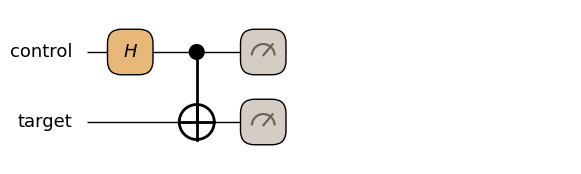

In [3]:
@qmc.qkernel
def bell_pair() -> tuple[qmc.Bit, qmc.Bit]:
    """Prepare and measure one Bell pair."""
    control = qmc.qubit("control")
    target = qmc.qubit("target")

    control = qmc.h(control)
    control, target = qmc.cx(control, target)

    return qmc.measure(control), qmc.measure(target)


bell_pair.draw()

Calling `estimate_resources()` on a qkernel returns a `ResourceEstimate`. This is not a measurement result obtained by executing the qkernel. It contains counts derived by Qamomile, including qubit width, logical gates, measurements, resets, and depth. Here, we display only the most representative values.

In [4]:
bell_estimate = bell_pair.estimate_resources()

print("qubits:", bell_estimate.qubits)
print("total gates:", bell_estimate.gates.total)
print("single-qubit gates:", bell_estimate.gates.single_qubit)
print("two-qubit gates:", bell_estimate.gates.two_qubit)
print("measurements:", bell_estimate.measurements.total)
print("depth:", bell_estimate.depth.depth)
print("gate depth:", bell_estimate.depth.gate_depth)

assert bell_estimate.qubits - 2 == 0
assert bell_estimate.gates.total - 2 == 0
assert bell_estimate.gates.single_qubit - 1 == 0
assert bell_estimate.gates.two_qubit - 1 == 0
assert bell_estimate.measurements.total - 2 == 0
assert bell_estimate.depth.depth - 3 == 0
assert bell_estimate.depth.gate_depth - 2 == 0

qubits: 2
total gates: 2
single-qubit gates: 1
two-qubit gates: 1
measurements: 2
depth: 3
gate depth: 2


`bell_pair` requires two qubits, two gates in total—one Hadamard gate and one CX gate—and two measurements. Because the measurement layer follows the gate sequence, the overall depth is three.

### 1.2 Estimate a Parameterized QKernel

A Bell state can be regarded as a two-qubit GHZ (Greenberger–Horne–Zeilinger) state. Generalize it to a GHZ state on `n` qubits by applying a Hadamard gate to the first qubit and connecting adjacent qubits sequentially with CX gates.

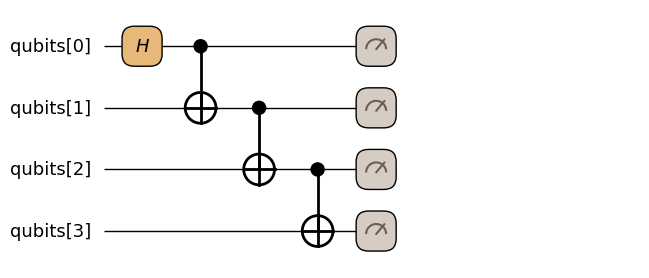

In [5]:
@qmc.qkernel
def ghz_state(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    """Prepare and measure a GHZ state with a symbolic width."""
    qubits = qmc.qubit_array(n, "qubits")
    qubits[0] = qmc.h(qubits[0])
    for index in qmc.range(n - 1):
        qubits[index], qubits[index + 1] = qmc.cx(
            qubits[index],
            qubits[index + 1],
        )
    return qmc.measure(qubits)


ghz_state.draw(n=4, fold_loops=False)

Resources can be estimated symbolically without supplying a value for `n`.

In [6]:
ghz_symbolic_estimate = ghz_state.estimate_resources()

print("parameters:", ghz_symbolic_estimate.parameters)
print("qubits:", ghz_symbolic_estimate.qubits)
print("total gates:", ghz_symbolic_estimate.gates.total)
print("single-qubit gates:", ghz_symbolic_estimate.gates.single_qubit)
print("two-qubit gates:", ghz_symbolic_estimate.gates.two_qubit)
print("measurements:", ghz_symbolic_estimate.measurements.total)
print("depth:", ghz_symbolic_estimate.depth.depth)
print("gate depth:", ghz_symbolic_estimate.depth.gate_depth)

n = ghz_symbolic_estimate.parameters["n"]
cx_count = n - 1
expected_depth = n + 1

assert sp.simplify(ghz_symbolic_estimate.qubits - n) == 0
assert sp.simplify(ghz_symbolic_estimate.gates.total - (cx_count + 1)) == 0
assert sp.simplify(ghz_symbolic_estimate.gates.single_qubit - 1) == 0
assert sp.simplify(ghz_symbolic_estimate.gates.two_qubit - cx_count) == 0
assert sp.simplify(ghz_symbolic_estimate.measurements.total - n) == 0
assert sp.simplify(ghz_symbolic_estimate.depth.depth - expected_depth) == 0
assert sp.simplify(ghz_symbolic_estimate.depth.gate_depth - (cx_count + 1)) == 0
assert ghz_symbolic_estimate.quality is qmc.EstimateQuality.CONSERVATIVE
assert any(
    assumption.source == "qkernel input domain"
    and "n >= 1" in assumption.message
    for assumption in ghz_symbolic_estimate.assumptions
)

parameters: {'n': n}
qubits: n
total gates: n
single-qubit gates: 1
two-qubit gates: n - 1
measurements: n
depth: n + 1
gate depth: n


### 1.3 Specialize an Estimate for a Particular Input

To obtain concrete values for a particular input, either pass `inputs` while estimating or apply `.substitute()` to an existing symbolic estimate.

| Method | When the value is applied | Best suited for |
|---|---|---|
| `estimate_resources(inputs={...})` | During resource estimation | Specializing array shapes, indices, branches, loop structure, and other structural facts from the start |
| `estimate.substitute(...)` | When evaluating an existing resource formula | Comparing the same symbolic estimate at several problem sizes |

First, use `inputs` to specialize `n=4` before estimation begins.

In [7]:
ghz_input_estimate = ghz_state.estimate_resources(
    inputs={"n": 4},
)

print("inputs -> qubits:", ghz_input_estimate.qubits)
print("inputs -> total gates:", ghz_input_estimate.gates.total)

assert ghz_input_estimate.qubits - 4 == 0
assert ghz_input_estimate.gates.total - 4 == 0
assert ghz_input_estimate.gates.single_qubit - 1 == 0
assert ghz_input_estimate.gates.two_qubit - (4 - 1) == 0
assert ghz_input_estimate.measurements.total - 4 == 0
assert ghz_input_estimate.depth.depth - (4 + 1) == 0
assert ghz_input_estimate.depth.gate_depth - 4 == 0

inputs -> qubits: 4
inputs -> total gates: 4


Next, apply `.substitute(n=4)` to the existing `ghz_symbolic_estimate`. This method does not analyze the qkernel again; it replaces `n` with four in the completed resource formulas.

In [8]:
ghz_substituted_estimate = ghz_symbolic_estimate.substitute(n=4)

print("substitute -> qubits:", ghz_substituted_estimate.qubits)
print("substitute -> total gates:", ghz_substituted_estimate.gates.total)

assert ghz_substituted_estimate.qubits - ghz_input_estimate.qubits == 0
assert ghz_substituted_estimate.gates.total - ghz_input_estimate.gates.total == 0
assert (
    ghz_substituted_estimate.gates.single_qubit - ghz_input_estimate.gates.single_qubit
    == 0
)
assert (
    ghz_substituted_estimate.gates.two_qubit - ghz_input_estimate.gates.two_qubit == 0
)
assert (
    ghz_substituted_estimate.measurements.total - ghz_input_estimate.measurements.total
    == 0
)
assert ghz_substituted_estimate.depth.depth - ghz_input_estimate.depth.depth == 0
assert (
    ghz_substituted_estimate.depth.gate_depth - ghz_input_estimate.depth.gate_depth == 0
)

substitute -> qubits: 4
substitute -> total gates: 4


For `ghz_state`, both methods produce the same qubit, gate, measurement, and depth values. However, the value is applied at a different stage, so this equivalence does not hold for every qkernel.

`.substitute()` only replaces values in existing formulas; it does not recompute qubit dependencies or depth. To see a difference between the two methods, consider a qkernel that applies a Hadamard gate to `qubits[0]` and then applies an X gate to `qubits[i]` through a symbolic index.

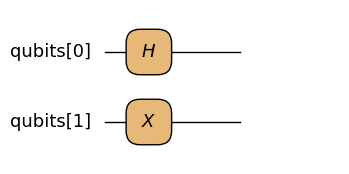

In [9]:
@qmc.qkernel
def symbolic_access(i: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    """Access qubits[0] and qubits[i] in a symbolic way."""
    qubits = qmc.qubit_array(i + 1, "qubits")
    qubits[0] = qmc.h(qubits[0])
    qubits[i] = qmc.x(qubits[i])
    return qubits


symbolic_access.draw(i=1)

Without a concrete `i`, the two gates might act on the same qubit, so the estimator safely serializes them and reports depth two.

In [10]:
access_symbolic_estimate = symbolic_access.estimate_resources()

print("symbolic -> depth:", access_symbolic_estimate.depth.depth)
assert access_symbolic_estimate.depth.depth - 2 == 0

symbolic -> depth: 2


Passing `inputs={"i": 0}` during estimation proves that both gates act on the same qubit, so the depth is two.

In [11]:
access_i0_estimate = symbolic_access.estimate_resources(inputs={"i": 0})

print("inputs, i=0 -> depth:", access_i0_estimate.depth.depth)
assert access_i0_estimate.depth.depth - 2 == 0

inputs, i=0 -> depth: 2


Passing `inputs={"i": 1}` during estimation proves that the two gates act on different qubits and may occupy the same layer, so the depth is one.

In [12]:
access_i1_estimate = symbolic_access.estimate_resources(inputs={"i": 1})

print("inputs, i=1 -> depth:", access_i1_estimate.depth.depth)
assert access_i1_estimate.depth.depth - 1 == 0

inputs, i=1 -> depth: 1


By contrast, applying `.substitute(i=1)` to the symbolic estimate does not recompute the dependency order that has already been chosen. The depth therefore remains two after substitution.

In [13]:
access_i1_substituted_estimate = access_symbolic_estimate.substitute(i=1)

print("substitute, i=1 -> depth:", access_i1_substituted_estimate.depth.depth)
assert access_i1_substituted_estimate.depth.depth - 2 == 0

substitute, i=1 -> depth: 2


## 2. Reading commonly used estimation results

The `ResourceEstimate` returned by `estimate_resources()` stores quantum-bit width (`.width`), quantum gate, measurement, and reset counts (`.gates`/`.measurements`/`.resets`), and depth (`.depth`) in separate fields. This section focuses on the fields you will inspect most often. Appendix lists every field.

### 2.1 Quantum-bit width

Quantum-bit width has the following fields:

- `width.input_qubits`: the number of quantum bits passed from the caller to the quantum kernel
- `width.allocated_qubits`: the number of quantum bits allocated in the body of the quantum kernel
- `width.clean_ancilla_qubits`: the number of ancillary quantum bits that must initially be in `|0>`
- `width.peak_qubits`: the maximum number of logical quantum bits needed simultaneously during execution
- `width.circuit_qubits`: the static circuit width, including inputs, every allocation site, and clean/dirty ancillas

`ResourceEstimate.qubits` is an alias for `width.peak_qubits`, and `ResourceEstimate.circuit_qubits` is an alias for `width.circuit_qubits`. We will inspect these values using the four-quantum-bit `ghz_state` from Section 1.

In [14]:
ghz_estimate = ghz_state.estimate_resources(inputs={"n": 4})

print("Peak quantum bits:", ghz_estimate.qubits)
print("Input quantum bits:", ghz_estimate.width.input_qubits)
print("Allocated quantum bits:", ghz_estimate.width.allocated_qubits)
print("Clean ancillas:", ghz_estimate.width.clean_ancilla_qubits)
print("Static circuit width:", ghz_estimate.circuit_qubits)

assert ghz_estimate.qubits - 4 == 0
assert ghz_estimate.width.input_qubits - 0 == 0
assert ghz_estimate.width.allocated_qubits - 4 == 0
assert ghz_estimate.width.clean_ancilla_qubits - 0 == 0
assert ghz_estimate.circuit_qubits - 4 == 0

Peak quantum bits: 4
Input quantum bits: 0
Allocated quantum bits: 4
Clean ancillas: 0
Static circuit width: 4


`ghz_state` does not receive quantum bits as arguments; it allocates four of them in its body. All four are live at the same time in this example, and no additional ancilla is needed, so both the peak width and static circuit width are four.

`qubits` and `circuit_qubits` can differ. In the next quantum kernel, the first quantum bit is measured, ending its lifetime, before another quantum bit is allocated.

In [15]:
@qmc.qkernel
def released_qubit_example() -> qmc.Qubit:
    """Measure one qubit before allocating its replacement."""
    first = qmc.qubit("first")
    _measured = qmc.measure(first)
    return qmc.qubit("second")

In [16]:
released_qubit_estimate = released_qubit_example.estimate_resources()

print("Peak quantum bits:", released_qubit_estimate.qubits)
print("Allocated quantum bits:", released_qubit_estimate.width.allocated_qubits)
print("Static circuit width:", released_qubit_estimate.circuit_qubits)

assert released_qubit_estimate.qubits - 1 == 0
assert released_qubit_estimate.width.allocated_qubits - 2 == 0
assert released_qubit_estimate.circuit_qubits - 2 == 0

Peak quantum bits: 1
Allocated quantum bits: 2
Static circuit width: 2


The two quantum bits are never used at the same time, so the peak width is one. The static circuit retains both allocation sites, however, so `circuit_qubits` is two.

### 2.2 Gate, measurement, and reset counts

In addition to the total, the gate-count fields show a breakdown by the number of quantum bits on which each gate acts. For example, `multi_qubit` counts logical gates acting on three or more quantum bits.

For an ordinary quantum kernel whose body can be analyzed, the breakdown by number of acted-on quantum bits sums to `total`.

In [17]:
print("Total gates:", ghz_estimate.gates.total)
print("Single-quantum-bit gates:", ghz_estimate.gates.single_qubit)
print("Two-quantum-bit gates:", ghz_estimate.gates.two_qubit)
print("Multi-quantum-bit gates:", ghz_estimate.gates.multi_qubit)

assert ghz_estimate.gates.total - 4 == 0
assert ghz_estimate.gates.single_qubit - 1 == 0
assert ghz_estimate.gates.two_qubit - 3 == 0
assert ghz_estimate.gates.multi_qubit - 0 == 0
assert (
    ghz_estimate.gates.total
    - (
        ghz_estimate.gates.single_qubit
        + ghz_estimate.gates.two_qubit
        + ghz_estimate.gates.multi_qubit
    )
    == 0
)

Total gates: 4
Single-quantum-bit gates: 1
Two-quantum-bit gates: 3
Multi-quantum-bit gates: 0


The four-quantum-bit `ghz_state` contains one Hadamard gate and three CX gates. Therefore, `single_qubit` is one, `two_qubit` is three, and the total gate count in `total` is four.

Measurements and resets are not included in the gate count; they are counted in separate fields.

In [18]:
print("Measurements:", ghz_estimate.measurements.total)
print("Resets:", ghz_estimate.resets.total)

assert ghz_estimate.measurements.total - 4 == 0
assert ghz_estimate.resets.total - 0 == 0

Measurements: 4
Resets: 0


Because all four quantum bits are measured, `measurements.total` is four. This quantum kernel contains no reset, so `resets.total` is zero. These values count measurement events per quantum bit and are not multiplied by the number of shots.

### 2.3 Depth

While the gate count represents the number of logical gate applications, depth represents the number of layers needed when all dependencies are preserved.

`depth.depth` is the length of the critical path through the entire quantum kernel. A critical path is the longest chain of operations whose execution order cannot be changed because of dependencies. `gate_depth`, `measurement_depth`, and `reset_depth` are depths computed with the same dependencies while only gates, measurements, or resets, respectively, contribute to the layer count. In general, adding the depths for the individual operation types does not reconstruct `depth.depth`.

In [19]:
print("Overall depth:", ghz_estimate.depth.depth)
print("Gate depth:", ghz_estimate.depth.gate_depth)
print("Measurement depth:", ghz_estimate.depth.measurement_depth)
print("Reset depth:", ghz_estimate.depth.reset_depth)

assert ghz_estimate.depth.depth - 5 == 0
assert ghz_estimate.depth.gate_depth - 4 == 0
assert ghz_estimate.depth.measurement_depth - 1 == 0
assert ghz_estimate.depth.reset_depth - 0 == 0

Overall depth: 5
Gate depth: 4
Measurement depth: 1
Reset depth: 0


In `ghz_state`, the Hadamard gate and three CX gates form four layers because they propagate state through the same quantum bits in sequence. One measurement layer is then needed, so the overall depth is five.

Gates that act on different quantum bits and have no dependency can instead occupy the same layer. The next quantum kernel uses two Hadamard gates, but they can run in parallel, so its gate depth is one.

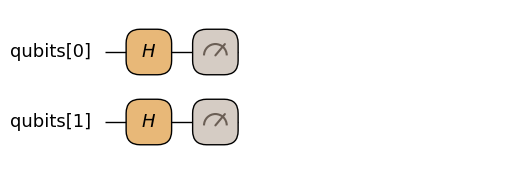

In [20]:
@qmc.qkernel
def parallel_hadamards() -> qmc.Vector[qmc.Bit]:
    """Apply two independent Hadamard gates and measure both qubits."""
    qubits = qmc.qubit_array(2, "qubits")
    qubits[0] = qmc.h(qubits[0])
    qubits[1] = qmc.h(qubits[1])
    return qmc.measure(qubits)


parallel_hadamards.draw()

In [21]:
parallel_estimate = parallel_hadamards.estimate_resources()

print("Total gates:", parallel_estimate.gates.total)
print("Gate depth:", parallel_estimate.depth.gate_depth)
print("Measurements:", parallel_estimate.measurements.total)
print("Measurement depth:", parallel_estimate.depth.measurement_depth)
print("Overall depth:", parallel_estimate.depth.depth)

assert parallel_estimate.gates.total - 2 == 0
assert parallel_estimate.depth.gate_depth - 1 == 0
assert parallel_estimate.measurements.total - 2 == 0
assert parallel_estimate.depth.measurement_depth - 1 == 0
assert parallel_estimate.depth.depth - 2 == 0

Total gates: 2
Gate depth: 1
Measurements: 2
Measurement depth: 1
Overall depth: 2


The two Hadamard gates fit in one gate layer, and the two measurements fit in one measurement layer. The gate and measurement counts are therefore both two, while the overall depth is two.

Operations outside a selected category are not removed from the dependency order when calculating category-specific depth. In the next quantum kernel, an RZZ gate between two Hadamard gates on different quantum bits connects them through dependencies.

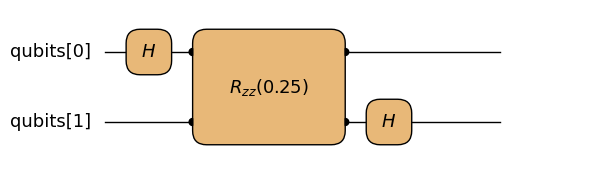

In [22]:
@qmc.qkernel
def category_depth_example() -> qmc.Vector[qmc.Qubit]:
    """Connect two Clifford gates through one rotation gate."""
    qubits = qmc.qubit_array(2, "qubits")
    qubits[0] = qmc.h(qubits[0])
    qubits[0], qubits[1] = qmc.rzz(qubits[0], qubits[1], 0.25)
    qubits[1] = qmc.h(qubits[1])
    return qubits


category_depth_example.draw()

The RZZ gate does not add a layer to `clifford_depth`, but it connects the dependencies of the Hadamard gates before and after it. As a result, `clifford_depth` is two even though the Hadamard gates act on different quantum bits. Likewise, the Hadamard gates do not add layers to `rotation_depth` or `non_clifford_depth`, but their dependencies are still preserved.

In [23]:
category_depth_estimate = category_depth_example.estimate_resources()

print("Overall depth:", category_depth_estimate.depth.depth)
print("Gate depth:", category_depth_estimate.depth.gate_depth)
print("Clifford depth:", category_depth_estimate.depth.clifford_depth)
print("Rotation-gate depth:", category_depth_estimate.depth.rotation_depth)
print("Non-Clifford depth:", category_depth_estimate.depth.non_clifford_depth)

assert category_depth_estimate.depth.depth - 3 == 0
assert category_depth_estimate.depth.gate_depth - 3 == 0
assert category_depth_estimate.depth.clifford_depth - 2 == 0
assert category_depth_estimate.depth.rotation_depth - 1 == 0
assert category_depth_estimate.depth.non_clifford_depth - 1 == 0

Overall depth: 3
Gate depth: 3
Clifford depth: 2
Rotation-gate depth: 1
Non-Clifford depth: 1


## 3. Assigning a cost to an Oracle

For an ordinary quantum kernel, Qamomile recursively follows the operations in its body to estimate resources. In a top-down design, however, you may define only the inputs and outputs before implementing some problem-specific operation.

Such an operation can be represented as a `qmc.Oracle` without an implementation. Because it has no internal gate sequence available for estimation, you provide its known cost either as a fixed value or through a callback.

### 3.1 Providing a fixed cost

When the cost of one call is known, pass a fixed `ResourceEstimate` to the `cost` argument of `qmc.Oracle`. Suppose the following Oracle acts on two quantum bits and uses two single-quantum-bit gates and three two-quantum-bit gates. We also know that some of its internal gates can run in parallel, giving it a gate depth of four.

A fixed cost is the base cost of applying the Oracle once in the usual way. Resource fields omitted from `cost` are treated as zero. Gate counts cannot recover internal dependencies or parallelism, so if depth is also needed, specify it explicitly with `DepthResources`.

In [24]:
fixed_lookup = qmc.Oracle(
    "fixed_lookup",
    num_qubits=2,
    cost=qmc.ResourceEstimate(
        gates=qmc.GateResources(
            total=5,
            single_qubit=2,
            two_qubit=3,
        ),
        depth=qmc.DepthResources(
            depth=4,
            gate_depth=4,
        ),
    ),
)

An Oracle can be called inside a quantum kernel just like any other quantum operation.

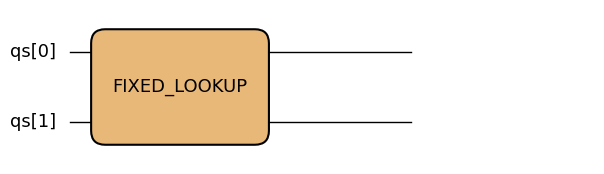

In [25]:
@qmc.qkernel
def with_fixed_oracle() -> qmc.Vector[qmc.Qubit]:
    """Apply one fixed-cost Oracle."""
    qs = qmc.qubit_array(2, "qs")
    return fixed_lookup(qs)


with_fixed_oracle.draw()

Estimating this quantum kernel combines the fixed cost assigned to the Oracle with the two quantum bits allocated by the caller.

In [26]:
fixed_oracle_estimate = with_fixed_oracle.estimate_resources()

print("Quantum bits:", fixed_oracle_estimate.qubits)
print("Total gates:", fixed_oracle_estimate.gates.total)
print("Single-quantum-bit gates:", fixed_oracle_estimate.gates.single_qubit)
print("Two-quantum-bit gates:", fixed_oracle_estimate.gates.two_qubit)
print("Gate depth:", fixed_oracle_estimate.depth.gate_depth)

assert fixed_oracle_estimate.qubits - 2 == 0
assert fixed_oracle_estimate.gates.total - 5 == 0
assert fixed_oracle_estimate.gates.single_qubit - 2 == 0
assert fixed_oracle_estimate.gates.two_qubit - 3 == 0
assert fixed_oracle_estimate.depth.depth - 4 == 0
assert fixed_oracle_estimate.depth.gate_depth - 4 == 0

Quantum bits: 2
Total gates: 5
Single-quantum-bit gates: 2
Two-quantum-bit gates: 3
Gate depth: 4


The estimate reflects the Oracle's five gates and depth of four exactly as specified. The caller quantum kernel allocates the two target quantum bits, so the peak width is two.

### 3.2 Computing a cost with a callback

When the number of quantum bits received by an Oracle is variable, specify a `CallableSignature` in its `signature`. When its cost also varies with the number of received quantum bits or other context, define the cost with a Python callback that receives an `OpaqueCostContext`. The next `CallableSignature` represents a function that receives one variable-length quantum-bit vector and returns one vector. For this Oracle's vector call, the input shape is propagated to the output.

The callback runs during resource estimation. `context.target_qubits` provides the number of target quantum bits, and `context.control_decomposition` contains the control-decomposition method selected for the current estimation.

In [27]:
def parallel_hadamard_layer_cost(
    context: qmc.OpaqueCostContext,
) -> qmc.ResourceEstimate:
    """Return the cost of one parallel Hadamard layer."""
    target_qubits = context.target_qubits
    layer_depth = sp.Piecewise(
        (0, sp.Eq(target_qubits, 0)),
        (1, True),
    )
    return qmc.ResourceEstimate(
        gates=qmc.GateResources(
            total=target_qubits,
            single_qubit=target_qubits,
            clifford=target_qubits,
        ),
        depth=qmc.DepthResources(
            depth=layer_depth,
            gate_depth=layer_depth,
            clifford_depth=layer_depth,
        ),
        control_decomposition=context.control_decomposition,
    )


parallel_hadamard_layer = qmc.Oracle(
    "parallel_hadamard_layer",
    signature=qmc.CallableSignature(
        inputs=[qmc.Vector[qmc.Qubit]],
        outputs=[qmc.Vector[qmc.Qubit]],
    ),
    cost=parallel_hadamard_layer_cost,
)

This callback returns the cost of applying one Hadamard gate to each target quantum bit in parallel. With at least one target, the gate count equals the number of quantum bits, but every gate can occupy the same layer, so the depth is one. The returned `control_decomposition` carries forward the setting received from the context. Next, we define a quantum kernel that applies this Oracle once to a variable-length quantum-bit array.

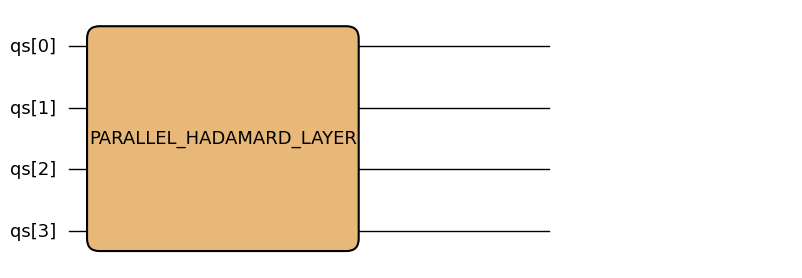

In [28]:
@qmc.qkernel
def with_callback_oracle(width: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    """Apply an Oracle whose cost follows the array width."""
    qs = qmc.qubit_array(width, "qs")
    return parallel_hadamard_layer(qs)


with_callback_oracle.draw(width=4)

Estimating without specifying `width` passes a symbolic target width to the callback, so the gate count and depth are returned as symbolic expressions as well.

In [29]:
callback_oracle_estimate = with_callback_oracle.estimate_resources()

print("Parameters:", callback_oracle_estimate.parameters)
print("Total gates:", callback_oracle_estimate.gates.total)
print("Gate depth:", callback_oracle_estimate.depth.gate_depth)

width = callback_oracle_estimate.parameters["width"]
expected_layer_depth = sp.Piecewise(
    (0, sp.Eq(width, 0)),
    (1, True),
)
assert sp.simplify(callback_oracle_estimate.qubits - width) == 0
assert sp.simplify(callback_oracle_estimate.gates.total - width) == 0
assert sp.simplify(callback_oracle_estimate.gates.single_qubit - width) == 0
assert sp.simplify(callback_oracle_estimate.gates.clifford - width) == 0
assert sp.simplify(callback_oracle_estimate.depth.depth - expected_layer_depth) == 0
assert (
    sp.simplify(callback_oracle_estimate.depth.gate_depth - expected_layer_depth) == 0
)
assert (
    sp.simplify(callback_oracle_estimate.depth.clifford_depth - expected_layer_depth)
    == 0
)

Parameters: {'width': width}
Total gates: width
Gate depth: Piecewise((0, Eq(width, 0)), (1, True))


The gate count contains the symbolic target width, and the depth is zero for an empty target and one otherwise.

## 4. Configuring the estimation method

`estimate_resources()` provides settings that select the model used to count the target structure. This section describes control decomposition and the treatment of operations whose cost is unknown.

### 4.1 Control decomposition

`control_decomposition` configures how controlled operations are counted. The default, `CLEAN_ANCILLA_TOFFOLI`, is a fixed decomposition model that uses Toffoli gates and clean ancillas initially in `|0>`. `ABSTRACT` counts a controlled operation as one multi-controlled operation without decomposing it.

The next example uses three control quantum bits to control one Hadamard gate.

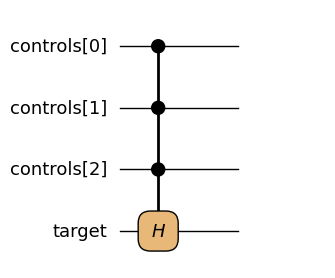

In [30]:
@qmc.qkernel
def three_controlled_hadamard() -> qmc.Qubit:
    """Apply one Hadamard gate under three coherent controls."""
    controls = qmc.qubit_array(3, "controls")
    target = qmc.qubit("target")
    controls, target = qmc.control(qmc.h, num_controls=3)(controls, target)
    return target


three_controlled_hadamard.draw()

First, estimate using the default `CLEAN_ANCILLA_TOFFOLI`. This model computes the conjunction of the three control conditions into two clean ancillas, applies the controlled Hadamard, and then uncomputes the conjunction.

In [31]:
decomposed_control_estimate = three_controlled_hadamard.estimate_resources()

print("Total gates after decomposition:", decomposed_control_estimate.gates.total)
print("Toffoli gates after decomposition:", decomposed_control_estimate.gates.toffoli)
print(
    "Clean ancillas used by decomposition:",
    decomposed_control_estimate.width.clean_ancilla_qubits,
)

assert decomposed_control_estimate.gates.total - 5 == 0
assert decomposed_control_estimate.gates.toffoli - 4 == 0
assert decomposed_control_estimate.width.clean_ancilla_qubits - 2 == 0
assert decomposed_control_estimate.qubits - 6 == 0

Total gates after decomposition:

 5
Toffoli gates after decomposition: 4
Clean ancillas used by decomposition: 2


Four Toffoli gates compute and uncompute the conjunction, so the total gate count is five when the controlled Hadamard is included.

Next, select `ABSTRACT`. This model counts the controlled Hadamard as one multi-controlled operation without decomposition and does not add decomposition ancillas.

In [32]:
abstract_control_estimate = three_controlled_hadamard.estimate_resources(
    control_decomposition=qmc.ControlDecomposition.ABSTRACT,
)

print("Total gates with ABSTRACT:", abstract_control_estimate.gates.total)
print(
    "Clean ancillas with ABSTRACT:",
    abstract_control_estimate.width.clean_ancilla_qubits,
)

assert abstract_control_estimate.gates.total - 1 == 0
assert abstract_control_estimate.width.clean_ancilla_qubits - 0 == 0
assert abstract_control_estimate.qubits - 4 == 0

Total gates with ABSTRACT: 1
Clean ancillas with ABSTRACT: 0


Below, we write the decomposition using Toffoli gates and clean ancillas explicitly, and confirm that its total gate count, Toffoli count, depth, and peak width match the `CLEAN_ANCILLA_TOFFOLI` estimate.

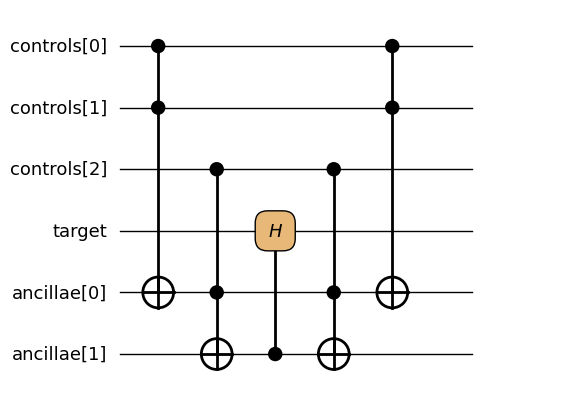

In [33]:
@qmc.qkernel
def three_controlled_hadamard_manually() -> qmc.Qubit:
    """Apply a manually decomposed three-controlled Hadamard gate."""
    controls = qmc.qubit_array(3, "controls")
    target = qmc.qubit("target")
    ancillae = qmc.qubit_array(2, "ancillae")

    controls[0], controls[1], ancillae[0] = qmc.ccx(
        controls[0],
        controls[1],
        ancillae[0],
    )
    controls[2], ancillae[0], ancillae[1] = qmc.ccx(
        controls[2],
        ancillae[0],
        ancillae[1],
    )
    ancillae[1], target = qmc.control(qmc.h)(ancillae[1], target)
    controls[2], ancillae[0], ancillae[1] = qmc.ccx(
        controls[2],
        ancillae[0],
        ancillae[1],
    )
    controls[0], controls[1], ancillae[0] = qmc.ccx(
        controls[0],
        controls[1],
        ancillae[0],
    )
    return target


three_controlled_hadamard_manually.draw()

Estimate the explicitly decomposed quantum kernel and compare it with the `CLEAN_ANCILLA_TOFFOLI` result.

In [34]:
manual_control_estimate = three_controlled_hadamard_manually.estimate_resources()

print("Manual decomposition total gates:", manual_control_estimate.gates.total)
print("Manual decomposition Toffoli gates:", manual_control_estimate.gates.toffoli)
print(
    "Quantum bits allocated by the manual decomposition:", manual_control_estimate.width.allocated_qubits
)
print(
    "Manual decomposition clean_ancilla_qubits:",
    manual_control_estimate.width.clean_ancilla_qubits,
)

assert (
    manual_control_estimate.gates.total - decomposed_control_estimate.gates.total == 0
)
assert (
    manual_control_estimate.gates.toffoli - decomposed_control_estimate.gates.toffoli
    == 0
)
assert manual_control_estimate.qubits - decomposed_control_estimate.qubits == 0
assert (
    manual_control_estimate.depth.depth - decomposed_control_estimate.depth.depth == 0
)
assert manual_control_estimate.width.allocated_qubits - 6 == 0
assert manual_control_estimate.width.clean_ancilla_qubits - 0 == 0

Manual decomposition total gates: 5
Manual decomposition Toffoli gates: 4
Quantum bits allocated by the manual decomposition: 6
Manual decomposition clean_ancilla_qubits: 0


Both the `CLEAN_ANCILLA_TOFFOLI` estimate and the explicitly decomposed quantum kernel use four Toffoli gates and one controlled Hadamard, with a peak width of six. The explicit quantum kernel allocates its two ancillas in its own body, so they are included in `allocated_qubits`. With `CLEAN_ANCILLA_TOFFOLI`, the estimation model adds two quantum bits as `clean_ancilla_qubits`, separately from the four allocated by the original quantum kernel.

### 4.2 Unknown resource policy

When estimating a quantum kernel that contains an Oracle without a cost, use `unknown_policy` to choose how the unknown part is handled. The default is `ERROR`, which raises `ValueError` instead of implicitly treating an unknown cost as zero.

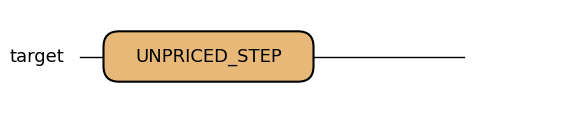

In [35]:
unpriced_step = qmc.Oracle(
    "unpriced_step",
    num_qubits=1,
)


@qmc.qkernel
def with_unpriced_oracle() -> qmc.Qubit:
    """Invoke an Oracle without a resource cost."""
    target = qmc.qubit("target")
    (target,) = unpriced_step(target)
    return target


with_unpriced_oracle.draw()

First, estimate without specifying `unknown_policy`, using the default `ERROR`. An Oracle without a cost is not implicitly treated as zero cost; it raises `ValueError`.

In [36]:
try:
    with_unpriced_oracle.estimate_resources()
except ValueError as error:
    print(error)
    assert "no body or opaque cost" in str(error)
else:
    raise AssertionError("An unpriced Oracle must fail by default.")

Cannot estimate resources for callable 'unpriced_step': no body or opaque cost is available.


If you want estimation to continue rather than fail when an unknown part is present, explicitly select `OPAQUE_CALL` or `ZERO_WITH_WARNING`.

`OPAQUE_CALL` does not guess the unknown gate count or width. Instead, it records one named call and one query.

In [37]:
opaque_call_estimate = with_unpriced_oracle.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.OPAQUE_CALL,
)

print("Opaque-call gates:", opaque_call_estimate.gates.total)
print("Opaque calls:", opaque_call_estimate.calls.calls_by_name)
print("Opaque queries:", opaque_call_estimate.calls.queries_by_name)

assert opaque_call_estimate.gates.total - 0 == 0
assert opaque_call_estimate.calls.calls_by_name == {"unpriced_step": 1}
assert opaque_call_estimate.calls.queries_by_name == {"unpriced_step": 1}
assert opaque_call_estimate.quality is qmc.EstimateQuality.UNKNOWN

Opaque-call gates: 0
Opaque calls: {'unpriced_step': 1}
Opaque queries: {'unpriced_step': 1}


`ZERO_WITH_WARNING` continues estimation by assuming zero for the unknown part and records that assumption in the result's `assumptions`. Note that this warning is recorded in the `.assumptions` field rather than emitted as a Python warning.

In [38]:
zero_warning_estimate = with_unpriced_oracle.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.ZERO_WITH_WARNING,
)

print("Zero-with-warning gates:", zero_warning_estimate.gates.total)
print("Zero-with-warning assumptions:")
for assumption in zero_warning_estimate.assumptions:
    print(f"- {assumption.message} (source: {assumption.source})")

assert zero_warning_estimate.gates.total - 0 == 0
assert zero_warning_estimate.calls.calls_by_name == {}
assert zero_warning_estimate.calls.queries_by_name == {}
assert any(
    assumption.message == "unknown callable counted as zero resources"
    and assumption.source == "unpriced_step"
    for assumption in zero_warning_estimate.assumptions
)
assert zero_warning_estimate.quality is qmc.EstimateQuality.UNKNOWN

Zero-with-warning gates: 0
Zero-with-warning assumptions:
- unknown callable counted as zero resources (source: unpriced_step)


| Policy | Treatment of unknown parts |
|---|---|
| `ERROR` | Default. Raises `ValueError` for an Oracle without a cost |
| `OPAQUE_CALL` | Does not guess gate cost and records one named call and query |
| `ZERO_WITH_WARNING` | Assumes zero for the unknown part and records that assumption in `assumptions` |

A zero gate count under `OPAQUE_CALL` or `ZERO_WITH_WARNING` does not mean that the unknown part contains no gates. In both cases, `quality` is `UNKNOWN`, indicating that some part could not be estimated. `unknown_policy` affects Oracles without a specified cost. An Oracle with a fixed cost or callback, as in Section 3, uses that cost. Therefore, explicitly specify a zero cost when zero is the intended cost.

## 5. Checking confidence in an estimate

In addition to resource values, inspect the result's `derivation`, `quality`, and `approximation` to understand how those values were calculated. These are three independent fields that answer different questions.

### 5.1 Three independent axes

| Field | What it tells you | Values |
|---|---|---|
| `derivation` | How the estimate was obtained | `STRUCTURAL` / `MODELED` |
| `quality` | What uncertainty the estimate contains | `EXACT` / `CONSERVATIVE` / `UNKNOWN` |
| `approximation` | Whether the estimate contains a mathematical approximation recognized by the estimator | `EXACT` / `APPROXIMATE` |

`derivation=STRUCTURAL` means the estimator recursively counted the defined quantum kernel and the selected decomposition rules. `MODELED` means it obtained the values from a cost assigned to an Oracle or from the selected `unknown_policy` for an Oracle without a cost.

`quality=EXACT` means the estimate matches the target being estimated, including the selected decomposition rules and declared costs. `CONSERVATIVE` is a safe value that does not underestimate, while `UNKNOWN` is a value that cannot be confirmed as either `EXACT` or `CONSERVATIVE`.

`approximation` describes whether the estimate includes a known approximation to an ideal mathematical operation, rather than how numerical resources were counted.

#### `bell_pair`: `STRUCTURAL / EXACT / EXACT`

For `bell_pair`, the estimator counts the cost exactly and without ambiguity from the defined quantum kernel. It also contains no mathematical approximation recognized by the estimator.

In [39]:
print("derivation:", bell_estimate.derivation.value)
print("quality:", bell_estimate.quality.value)
print("approximation:", bell_estimate.approximation.value)

assert bell_estimate.derivation is qmc.EstimateDerivation.STRUCTURAL
assert bell_estimate.quality is qmc.EstimateQuality.EXACT
assert bell_estimate.approximation is qmc.ApproximationStatus.EXACT

derivation: structural
quality: exact
approximation: exact


#### Fixed-cost Oracle: `MODELED / EXACT / EXACT`

The internal structure of `fixed_lookup` is not visible, but the user specifies the cost of one call. Its `derivation` is therefore `MODELED`, and its `quality` is `EXACT` with respect to the declared base cost.

In [40]:
print("derivation:", fixed_oracle_estimate.derivation.value)
print("quality:", fixed_oracle_estimate.quality.value)
print("approximation:", fixed_oracle_estimate.approximation.value)

assert fixed_oracle_estimate.derivation is qmc.EstimateDerivation.MODELED
assert fixed_oracle_estimate.quality is qmc.EstimateQuality.EXACT
assert fixed_oracle_estimate.approximation is qmc.ApproximationStatus.EXACT

derivation: modeled
quality: exact
approximation: exact


#### Control decomposition with clean ancillas: `STRUCTURAL / CONSERVATIVE / EXACT`

`CLEAN_ANCILLA_TOFFOLI` decomposes controlled operations in the defined quantum kernel with a fixed algorithmic model and produces a safe cost. This is not a mathematical approximation, so `approximation` is `EXACT`.

In [41]:
print("derivation:", decomposed_control_estimate.derivation.value)
print("quality:", decomposed_control_estimate.quality.value)
print("approximation:", decomposed_control_estimate.approximation.value)

assert decomposed_control_estimate.derivation is qmc.EstimateDerivation.STRUCTURAL
assert decomposed_control_estimate.quality is qmc.EstimateQuality.CONSERVATIVE
assert decomposed_control_estimate.approximation is qmc.ApproximationStatus.EXACT

derivation: structural
quality: conservative
approximation: exact


#### Oracle without a cost: `MODELED / UNKNOWN / EXACT`

`OPAQUE_CALL` records an Oracle without a cost as a named call and query. Its `quality` is `UNKNOWN` because the relationship to a concrete gate cost is unknown, but it does not introduce a mathematical approximation recognized by the estimator.

In [42]:
print("derivation:", opaque_call_estimate.derivation.value)
print("quality:", opaque_call_estimate.quality.value)
print("approximation:", opaque_call_estimate.approximation.value)

assert opaque_call_estimate.derivation is qmc.EstimateDerivation.MODELED
assert opaque_call_estimate.quality is qmc.EstimateQuality.UNKNOWN
assert opaque_call_estimate.approximation is qmc.ApproximationStatus.EXACT

derivation: modeled
quality: unknown
approximation: exact


#### Time evolution under noncommuting Pauli terms: `STRUCTURAL / EXACT / APPROXIMATE`

Finally, apply time evolution under a sum of noncommuting X and Z terms to one quantum bit. We approximate the ideal Hamiltonian time evolution with a first-order Lie–Trotter product formula and estimate the resources used by that implementation.

In [43]:
@qmc.qkernel
def one_qubit_pauli_evolution(
    hamiltonian: qmc.Observable,
    time: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    """Apply one Pauli-sum evolution to a single qubit."""
    target = qmc.qubit_array(1, "target")
    return qmc.pauli_evolve(target, hamiltonian, time)

Provide the Hamiltonian and time through `inputs` during estimation, then inspect the three metadata fields.

In [44]:
noncommuting_evolution_estimate = one_qubit_pauli_evolution.estimate_resources(
    inputs={
        "hamiltonian": qmo.X(0) + qmo.Z(0),
        "time": 0.25,
    },
)

print("derivation:", noncommuting_evolution_estimate.derivation.value)
print("quality:", noncommuting_evolution_estimate.quality.value)
print("approximation:", noncommuting_evolution_estimate.approximation.value)

assert noncommuting_evolution_estimate.derivation is qmc.EstimateDerivation.STRUCTURAL
assert noncommuting_evolution_estimate.quality is qmc.EstimateQuality.EXACT
assert (
    noncommuting_evolution_estimate.approximation is qmc.ApproximationStatus.APPROXIMATE
)

derivation: structural
quality: exact
approximation: approximate


This example counts the gates in the selected first-order Lie–Trotter product formula exactly, so `quality=EXACT`. The product formula itself approximates the ideal time evolution, however, so `approximation=APPROXIMATE`.

### 5.2 Assumptions

`assumptions` contains specific premises and reasons that the other three fields alone cannot express. These include not only model assumptions but also unresolved valid-input conditions used to simplify resource expressions. When the resource estimator can derive valid-input conditions from qkernel input types, array shapes including qubit-array shapes, array element accesses, or view coverage, it simplifies resource expressions over that domain and retains any unresolved conditions in `assumptions`. Each item has a descriptive `message` and a `source` identifying the responsible operation or other origin. A valid-input condition specifies the domain over which an expression applies; by itself, it does not reduce `quality` from `EXACT`. In the GHZ example above, the qubits become ready at different times after the CX chain. The current estimator conservatively relates this loop to the subsequent `measure(qubits)` using the longest latency of the whole loop rather than each qubit's individual completion time, so it may schedule measurements of earlier-ready qubits later than necessary. This makes `quality` `CONSERVATIVE`. In this GHZ qkernel, however, the last-ready qubit also determines the actual total depth, so the estimated depth `n + 1` matches the actual schedule. This is separate from simplification over the valid input domain.

An estimate produced with `ZERO_WITH_WARNING` records that an Oracle without a cost was counted as zero.

In [45]:
print("Unknown-cost assumptions:")
for assumption in zero_warning_estimate.assumptions:
    print(f"- {assumption.message} (source: {assumption.source})")

assert any(
    assumption.message == "unknown callable counted as zero resources"
    for assumption in zero_warning_estimate.assumptions
)

Unknown-cost assumptions:
- unknown callable counted as zero resources (source: unpriced_step)


Time evolution under noncommuting Pauli terms records that it contains a mathematical approximation.

In [46]:
print("Pauli-evolution assumptions:")
for assumption in noncommuting_evolution_estimate.assumptions:
    print(f"- {assumption.message} (source: {assumption.source})")

assert any(
    "first-order Lie-Trotter" in assumption.message
    for assumption in noncommuting_evolution_estimate.assumptions
)

Pauli-evolution assumptions:
- Noncommuting Pauli terms are counted as one first-order Lie-Trotter product-formula step in Hamiltonian term order. (source: PauliEvolveOp)


## Appendix: All `ResourceEstimate` fields

Resource fields may contain not only concrete integers but also SymPy expressions that depend on problem size. The representative fields covered in Section 2 are usually sufficient, but this appendix lists every public field for reference.

### `ResourceEstimate`

| Field | Description |
|---|---|
| `width` | Estimates of logical quantum-bit width and ancillas |
| `gates` | Estimates of logical gate counts |
| `measurements` | Estimate of measurement-event count |
| `resets` | Estimate of reset count |
| `depth` | Estimates of logical depth |
| `calls` | Counts of recorded opaque calls and queries by name |
| `parameters` | Mapping from unresolved symbolic parameter names to SymPy symbols |
| `assumptions` | Estimation premises, including model assumptions and unresolved valid-input conditions used to simplify expressions; each item has a `message` and `source` |
| `derivation` | Whether the estimate is `STRUCTURAL`, derived from the quantum kernel itself, or `MODELED`, derived using a cost or policy |
| `quality` | Whether uncertainty in the estimate is `EXACT`, `CONSERVATIVE`, or `UNKNOWN` |
| `approximation` | Whether recognized mathematical approximation is `EXACT` or `APPROXIMATE` |
| `control_decomposition` | Coherent-control decomposition method used for estimation |
| `trace` | Diagnostic tree retained only when `trace=True`; normally `None` |

### Width

`estimate.width` is a `WidthResources`.

| Field | Description |
|---|---|
| `input_qubits` | Number of quantum bits passed by the caller |
| `allocated_qubits` | Number of quantum bits at static allocation sites in the body |
| `clean_ancilla_qubits` | Peak demand for ancillas that must start in `|0>` and be returned to `|0>` after use |
| `dirty_ancilla_qubits` | Peak demand for ancillas borrowed in an arbitrary initial state and restored after use |
| `peak_qubits` | Maximum number of logical quantum bits live simultaneously during execution |

`allocated_qubits`, `clean_ancilla_qubits`, and `dirty_ancilla_qubits` are separate categories. Clean and dirty ancillas are not subdivisions of `allocated_qubits`.

### Gates

`estimate.gates` is a `GateResources`.

| Field | Description |
|---|---|
| `total` | Total number of logical gates, excluding measurements and resets |
| `single_qubit` | Number of gates acting on one quantum bit |
| `two_qubit` | Number of gates acting on two quantum bits |
| `multi_qubit` | Number of gates acting on three or more quantum bits |
| `clifford` | Number of Clifford gates |
| `rotation` | Number of rotation gates such as RX, RY, RZ, P, CP, and RZZ |
| `t` | Number of T and T-dagger gates |
| `toffoli` | Number of Toffoli gates |
| `non_clifford` | Number of non-Clifford gates |

`single_qubit`, `two_qubit`, and `multi_qubit` classify gates by how many quantum bits they act on. The fields from `clifford` onward classify gates by type, so the two classifications overlap and should not all be added together. Also, when only part of an Oracle's cost is specified, the breakdown by number of acted-on quantum bits may not sum to `total`.

### Measurements and resets

| Field | Description |
|---|---|
| `estimate.measurements.total` | Number of measurement events per quantum bit; measuring `N` quantum bits increases it by `N` |
| `estimate.resets.total` | Number of explicit resets per quantum bit |

Measurements and resets are not included in `gates.total`.

### Depth

`estimate.depth` is a `DepthResources`.

| Field | Description |
|---|---|
| `depth` | Length of the overall critical path, with gates, measurements, and resets contributing layers |
| `gate_depth` | Depth with only gates contributing layers |
| `measurement_depth` | Depth with only measurements contributing layers |
| `reset_depth` | Depth with only resets contributing layers |
| `clifford_depth` | Depth with only Clifford gates contributing layers |
| `rotation_depth` | Depth with only rotation gates contributing layers |
| `t_depth` | Depth with only T and T-dagger gates contributing layers |
| `toffoli_depth` | Depth with only Toffoli gates contributing layers |
| `non_clifford_depth` | Depth with only non-Clifford gates contributing layers |

For category-specific depth, operations outside the selected category do not increase the layer count, but their dependencies and ordering are still preserved. Adding these fields does not produce `depth.depth`.

### Calls and queries

`estimate.calls` is a `CallResources`.

| Field | Description |
|---|---|
| `calls_by_name` | Number of named calls left unexpanded or explicitly declared by a cost |
| `queries_by_name` | Number of algorithmic Oracle queries explicitly declared or modeled, grouped by name |

Calls to ordinary quantum kernels whose bodies can be analyzed are recursively expanded, so they do not remain in `calls_by_name`. `OPAQUE_CALL` records one in both fields as its no-information rule, but calls and queries are fields with different meanings.

### Convenience aliases

The following properties are aliases or computed values that provide shorter access to commonly used fields.

| Property | Corresponding value |
|---|---|
| `estimate.qubits` | `estimate.width.peak_qubits` |
| `estimate.width.circuit_qubits` | `input_qubits + allocated_qubits + clean_ancilla_qubits + dirty_ancilla_qubits` |
| `estimate.circuit_qubits` | `estimate.width.circuit_qubits` |
| `estimate.gates.t_gates` | `estimate.gates.t` |
| `estimate.gates.clifford_gates` | `estimate.gates.clifford` |
| `estimate.gates.rotation_gates` | `estimate.gates.rotation` |
| `estimate.calls.oracle_calls` | `estimate.calls.calls_by_name` |
| `estimate.calls.oracle_queries` | `estimate.calls.queries_by_name` |

## Summary

- `estimate_resources()` estimates algorithm-level resources before transpiling to a particular engine.
- A parameterized quantum kernel can be estimated symbolically. Use `inputs` when concretizing its structure during estimation, and `.substitute()` when evaluating an expression that has already been obtained.
- For an Oracle without a body, define the base cost of one call with either a fixed cost or callback.
- Inspect `derivation`, `quality`, `approximation`, and `assumptions` to understand how a resource estimate was calculated.